#**Salary Prediction using Years of Experience**

#Import Required Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Load the Dataset

In [ ]:
# Load dataset
df = pd.read_csv("Salary_Data.csv")

In [ ]:
# Display first 5 rows
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


#Understand the Dataset

Exploratory Data Analysis (EDA)

In [ ]:
0 # Dataset shape
df.shape

(30, 2)

In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
# Statistical summary
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


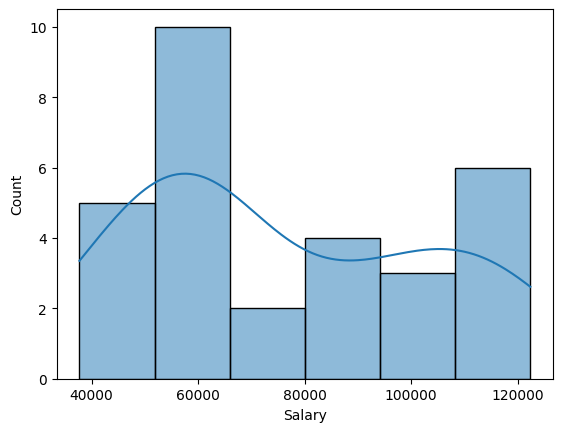

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["Salary"], kde=True)
plt.show()

#Check Missing Values

In [ ]:
# Check missing values
df.isnull().sum()

,0
YearsExperience,0
Salary,0


#Select Feature and Target

Simple Linear Regression → only one feature

X = Years of Experience

y = Salary

In [ ]:
# Feature (input)
X = df[['YearsExperience']]

# Target (output)
y = df['Salary']

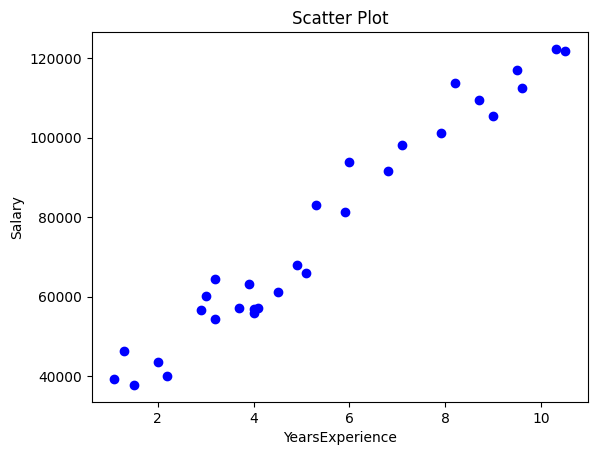

In [ ]:
plt.scatter(X, y, color='blue')
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Scatter Plot")
plt.show()

#Train–Test Split

80% data → training

20% data → testing

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Initialize Simple Linear Regression Model

LinearRegression() implements
y = mX + c

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Create Linear Regression model
model = LinearRegression()

#Train the Model

Model learns:

slope (m)

intercept (c)

In [ ]:
# Train model
model.fit(X_train, y_train)

LinearRegression()

#Model Parameters

coef_ → slope (m)

intercept_ → intercept (c)

In [ ]:
# Display learned parameters
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 9423.815323030976
Intercept: 25321.583011776813


# Make Predictions

Predict salary for unseen experience values

In [ ]:
# Predict salary on test data
y_pred = model.predict(X_test)

In [ ]:
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [ ]:
y_train

,Salary
28,122391.0
24,109431.0
12,56957.0
0,39343.0
4,39891.0
16,66029.0
5,56642.0
13,57081.0
11,55794.0
22,101302.0


In [ ]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [ ]:
y_test

,Salary
27,112635.0
15,67938.0
23,113812.0
17,83088.0
8,64445.0
9,57189.0


In [ ]:
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

#Model Evaluation

MSE → average squared error

RMSE → error in salary units

R² Score → goodness of fit

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 49830096.85590839
Root Mean Squared Error: 7059.04362190151
R² Score: 0.9024461774180497


#Visualization (Regression Line)

Blue dots → actual data

Red line → predicted regression line

In [ ]:
# Data visualization
import matplotlib.pyplot as plt

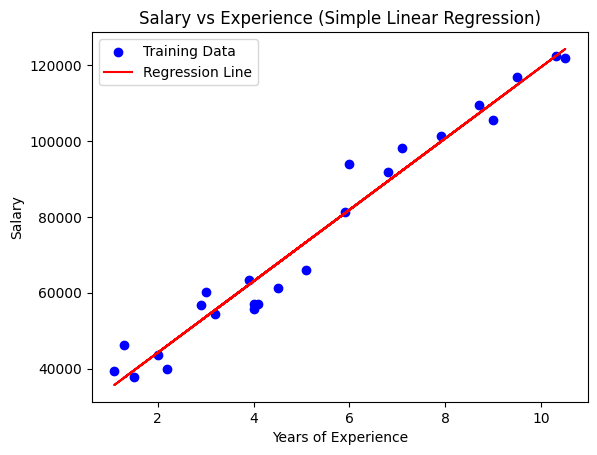

In [ ]:
# Plot regression line
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, model.predict(X_train), color='red', label='Regression Line')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience (Simple Linear Regression)")
plt.legend()
plt.show()

#Test Data Visualization

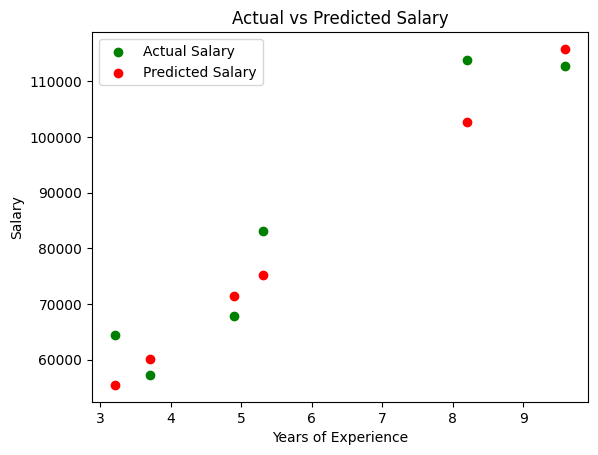

In [ ]:
# Test data comparison
plt.scatter(X_test, y_test, color='green', label='Actual Salary')
plt.scatter(X_test, y_pred, color='red', label='Predicted Salary')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.show()